# A Probabilistic U-Net with a post-hoc consensus-selection head

**Medical Images Processing with Deep Learning (336033)**

A PyTorch reimplementation of Kohl et al., *A Probabilistic U-Net for Segmentation of
Ambiguous Images* (NeurIPS 2018, [arXiv:1806.05034](https://arxiv.org/abs/1806.05034)),
trained on LIDC-IDRI and extended in two independent directions.

| phase | what it is | outcome |
|---|---|---|
| **1** | faithful reproduction — architecture, augmentation, five-step LR decay, the paper's 240k-iteration budget | the reference for everything below |
| **2** | one config flag: a **full-covariance** latent Gaussian in place of the paper's axis-aligned one | GED improved, the pre-registered mechanism refuted |
| **3** | a **post-hoc consensus-selection head** that picks one sample out of many without ground truth | recovers most of the headroom a size prior leaves |

The test split is the results split: it was evaluated once, after every threshold,
denominator and hyperparameter had been frozen. Validation drove the development decisions
and appears only where a quantity exists nowhere else, labelled `VAL`. Sections 0–6 render
recorded predictions and published tables, section 7 trains a small model to show the
pipeline executes, and section 8 runs the test suite.

In [1]:
# Locate the repository, or clone it when this notebook is opened straight from the badge.
REPO_REF = "main"          # tag or branch to clone when the repository is not on disk
REPO_URL = "https://github.com/RanWeisberg/prob-unet-consensus-selection.git"

import os, subprocess, sys
from pathlib import Path

MARKERS = ("pyproject.toml", "data/processed/showcase.npz")

here = Path.cwd().resolve()
candidates = [here, *here.parents,
              Path("/content/prob-unet-consensus-selection"),
              here / "prob-unet-consensus-selection"]
searched, ROOT = [], None
for candidate in candidates:
    searched.append(candidate)
    if all((candidate / marker).exists() for marker in MARKERS):
        ROOT = candidate
        break

if ROOT is None:
    target = (Path("/content") if Path("/content").is_dir() else here)
    target = target / "prob-unet-consensus-selection"
    print(f"repository not on disk; cloning {REPO_REF} into {target}")
    clone = subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", REPO_REF, REPO_URL, str(target)],
        capture_output=True, text=True,
    )
    if clone.returncode != 0:
        print(clone.stdout)
        print(clone.stderr)
        raise RuntimeError(f"git clone failed with exit code {clone.returncode}; "
                           f"git's own output is above")
    searched.append(target)
    if all((target / marker).exists() for marker in MARKERS):
        ROOT = target

if ROOT is None:
    raise FileNotFoundError(
        "could not locate the repository root. A root must contain ALL of "
        f"{MARKERS}.\nSearched:\n  " + "\n  ".join(str(p) for p in searched)
    )

os.chdir(ROOT)                      # configs/ and scripts/ use repo-root-relative paths
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import torch
print(f"repo root : {ROOT}")
print(f"python    : {sys.version.split()[0]}")
print(f"torch     : {torch.__version__}")

repository not on disk; cloning main into /content/prob-unet-consensus-selection
repo root : /content/prob-unet-consensus-selection
python    : 3.12.13
torch     : 2.11.0+cpu


In [2]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from probunet.notebook import (
    PALETTE as CLR, RC_PARAMS, bucket_ged_figure, case_arrays, composition_figure,
    demo_loss_figure, demo_samples_figure, denominator_figure, describe_monotonicity,
    graders_figure, load_manifest, load_results, phase2_case_figure,
    print_export_verification, samples_figure, score_agreement_figure, score_bars,
    selection_case_figure, set_a_guard_line, stat as val, table,
)

plt.rcParams.update(RC_PARAMS)

RESULTS = ROOT / "results"
SHOW = np.load(ROOT / "data" / "processed" / "showcase.npz", allow_pickle=False)
MAN = load_manifest(SHOW)
res = lambda name: load_results(RESULTS, name)      # noqa: E731 -- a binding, not logic
case = lambda prefix: case_arrays(SHOW, prefix)     # noqa: E731

print(f"showcase.npz : {len(SHOW.files)} arrays, "
      f"{(ROOT / 'data/processed/showcase.npz').stat().st_size / 1024**2:.2f} MiB")
print(f"results/     : {len(sorted(RESULTS.glob('*.json')))} tracked JSON files\n")
print_export_verification(MAN)

showcase.npz : 90 arrays, 0.46 MiB
results/     : 18 tracked JSON files

  MATCHED  consensus_selection_test.json                   6 figures x 5 buckets
  MATCHED  consensus_selection_modernized_test.json        6 figures x 5 buckets
  MATCHED  evaluation_test_baseline-short.json             GED @ 1, 4, 8, 16 (mean, median, std)
  MATCHED  evaluation_test_modernized-short.json           GED @ 1, 4, 8, 16 (mean, median, std)
  export 93f7ccb, 2026-08-11T10:43:35 UTC, no tolerance


---
# 0. Provenance

Full-length training ran on a local RTX 3070 Ti over several days, and the predictions
rendered below come from a recorded export of those runs. There are two Phase 1 arms:
`baseline` is the full-length run at the paper's budget and is the frozen base the
selection head attaches to, while `baseline-short` exists as the matched-pair control for
Phase 2 — it shares budget, schedule, split, seed and batch size with `modernized-short`
and differs from it in one config line. Comparing `modernized-short` against the
full-length `baseline` would confound the covariance change with a budget change.

In [3]:
rows = [[name,
         v["checkpoint"].replace("\\", "/"),
         v["epoch"],
         v["checkpoint_git_revision"],
         v["latent_covariance"],
         f'{v["parameter_count"]:,}',
         (v["base_parameter_sha256"] or "—")[:12],
         (v["base_checkpoint"] or "—").replace("\\", "/")]
        for name, v in MAN["variants"].items()]
table(["run", "checkpoint", "best ep", "git SHA", "latent", "params", "base sha256",
       "frozen base"], rows,
      title="Every checkpoint behind a number in this notebook",
      note="\nA frozen base is identified by the sha256 of its parameter values, not by "
           "its filename.")

print()
table(["field", "value"], [
    ["split", MAN["split"]],
    ["patches", f'{MAN["n_patches"]:,}'],
    ["eval seed", MAN["eval_seed"]],
    ["samples / image", MAN["n_samples"]],
    ["GED sample counts", ", ".join(str(n) for n in MAN["ged_sample_counts"])],
    ["torch", MAN["torch_version"]],
    ["device", MAN["device"]],
    ["platform", MAN["environment"]["platform"]],
    ["export git SHA", MAN["export_git_revision"]],
], title="Evaluation environment")

Every checkpoint behind a number in this notebook
run                        checkpoint                                          best ep  git SHA        latent    params      base sha256   frozen base                              
-------------------------  --------------------------------------------------  -------  -------------  --------  ----------  ------------  -----------------------------------------
baseline_short                        runs/baseline-short/checkpoints/best.pt       57        2c0a4ec  diagonal  27,499,098             —                                          —
modernized_short                    runs/modernized-short/checkpoints/best.pt       50  31a50e6-dirty      full  27,514,488             —                                          —
selection_head                        runs/selection-head/checkpoints/best.pt       29        023fb5b  diagonal  27,617,724  b1887d8d242f          runs/baseline/checkpoints/best.pt
selection_head_modernized  runs/selection-hea

---
# 1. Four graders, no single ground truth

Each LIDC patch carries four independent expert annotations and they disagree; up to three
of the four may be empty, which is signal about lesion *existence* rather than noise. Every
table below is stratified by the number of non-empty grader masks — bucket 1 is maximum
disagreement about existence, bucket 4 disagreement about extent only — because the two
regimes behave differently and an aggregate over them hides the difference. The **soft
consensus**, the equal-weighted average of the four masks, is the Phase 3 selection target
and only that: GED and every other distribution metric keeps the four masks separate.
Equal weighting is an explicit assumption, since LIDC's annotators are anonymous and carry
no identity across patches, so per-grader reliability cannot be estimated.

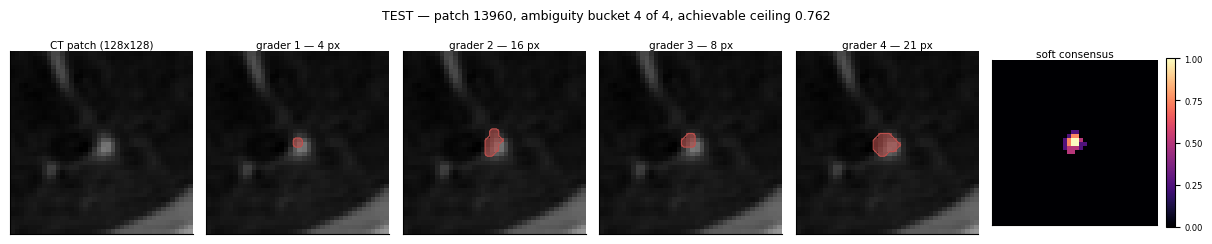

TEST — the best score any binary mask could reach against the soft target
ambiguity bucket  patches  achievable ceiling
----------------  -------  ------------------
1 grader              992              0.4000
2 graders             551              0.5833
3 graders             525              0.7347
4 graders             951              0.8878
all                 3,019              0.6453

A hard 0/1 candidate cannot reach 1.0 against a soft target, so every soft-consensus score in
section 4 is read against these ceilings or against the oracle, never against 1.0.


In [4]:
graders_figure(SHOW, "b2")

ceilings = res("consensus_selection_test.json")["buckets"]
table(["ambiguity bucket", "patches", "achievable ceiling"],
      [[k, f'{ceilings[k]["n"]:,}', f'{val(ceilings[k], "ceiling"):.4f}'] for k in ceilings],
      title="TEST — the best score any binary mask could reach against the soft target",
      note="\nA hard 0/1 candidate cannot reach 1.0 against a soft target, so every "
           "soft-consensus score in\nsection 4 is read against these ceilings or against "
           "the oracle, never against 1.0.")

---
# 2. Phase 1 — the reproduction

Appendix H.1 as specified: four down- and four up-sampling steps, three 3×3 convolutions
per scale, 32 base channels, a six-dimensional latent broadcast and concatenated to the
last U-Net activation, `f_comb` as three 1×1 convolutions, average-pool down, bilinear up,
He-normal initialisation, the paper's augmentation, its five-step learning-rate decay and
its 240k-iteration budget; the departures are itemised in `DEVIATIONS.md`. Drawing *m*
samples for one image re-runs only `f_comb` rather than the whole U-Net, which is what
makes the selection head of section 4 cheap. The paper reports no LIDC GED value — its
Table 2 is Cityscapes and LIDC appears only as a scatter plot — so section 3 uses Bhat et
al. ([arXiv:2207.12872](https://arxiv.org/abs/2207.12872)) on the same preprocessed data
as an external sanity range instead.

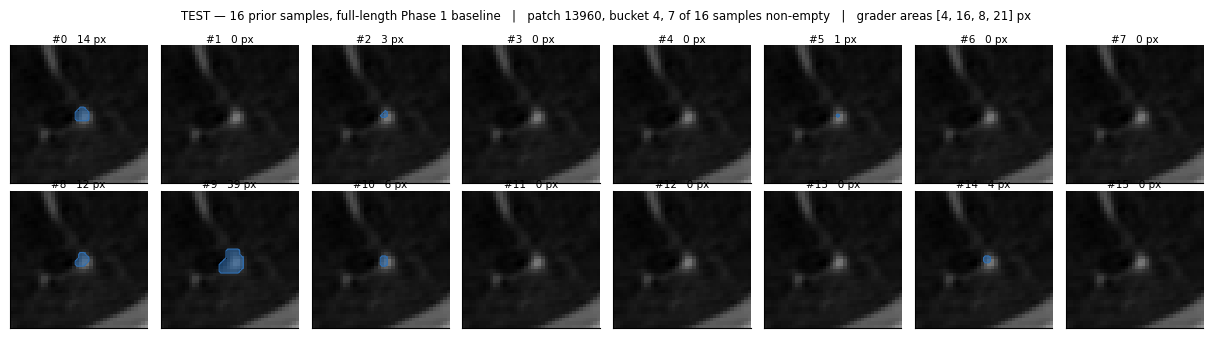

TEST — full-length Phase 1 baseline, GED^2 by sample count (lower is better)
n samples  GED^2   median  IQR   
---------  ------  ------  ------
1          0.7523  0.5400  1.0907
4          0.4062  0.2519  0.3907
8          0.3498  0.2161  0.3338
16         0.3211  0.1899  0.3280

GED^2 falls monotonically with sample count, the qualitative claim the paper's Figure 4a supports.

TEST — single-sample quality, and a predictor that models no ambiguity at all
quantity                    value 
--------------------------  ------
patches                      3,019
median lesion area           43 px
random-sample Dice @16      0.4621
oracle Dice @16             0.6857
per-grader oracle Dice @16  0.8395
Hungarian-matched IoU @16   0.7635
all-empty predictor GED^2   0.8482


In [5]:
samples_figure(SHOW, "b2", "TEST — 16 prior samples, full-length Phase 1 baseline")

b = res("evaluation_test_baseline.json")
agg = b["aggregate_over_all_patches"]
counts = b["sample_counts"]
n = counts[-1]

table(["n samples", "GED^2", "median", "IQR"],
      [[c, f'{val(agg, f"ged@{c}"):.4f}', f'{val(agg, f"ged@{c}", "median"):.4f}',
        f'{val(agg, f"ged@{c}", "iqr"):.4f}'] for c in counts],
      title="TEST — full-length Phase 1 baseline, GED^2 by sample count (lower is better)",
      note="\nGED^2 falls monotonically with sample count, the qualitative claim the "
           "paper's Figure 4a supports.")

print()
table(["quantity", "value"], [
    ["patches", f'{agg["n_patches"]:,}'],
    ["median lesion area", f'{agg["lesion_area_median_px"]:.0f} px'],
    [f"random-sample Dice @{n}", f'{val(agg, f"random_sample_dice@{n}"):.4f}'],
    [f"oracle Dice @{n}", f'{val(agg, f"oracle_dice@{n}"):.4f}'],
    [f"per-grader oracle Dice @{n}", f'{val(agg, f"oracle_dice_per_grader@{n}"):.4f}'],
    [f"Hungarian-matched IoU @{n}", f'{val(agg, f"hungarian_iou@{n}"):.4f}'],
    ["all-empty predictor GED^2", f'{val(agg, "empty_ged"):.4f}'],
], title="TEST — single-sample quality, and a predictor that models no ambiguity at all")

---
# 3. Phase 2 — a full-covariance latent

The paper's prior and posterior emit an axis-aligned Gaussian, which forces the six latent
dimensions to be mutually independent. Phase 2 replaces it with a full covariance
parameterised by its Cholesky factor `L`, so `Σ = L Lᵀ` is positive-definite by
construction and the dimensions can correlate. Graders do not disagree in independent
per-dimension wiggles — when a boundary is ambiguous, several aspects of the shape move
together — so the change targets GED directly rather than by side effect. It arrives behind
one config flag: the semantic diff between `baseline.yaml` and `modernized.yaml` is two
lines.

In [6]:
comp = res("comparison_test.json")
arms = ["baseline-short", "modernized-short"]
A = {a: comp["variants"][a]["aggregate_over_all_patches"] for a in arms}
N = comp["sample_counts"][-1]
g0, g1 = val(A[arms[0]], f"ged@{N}"), val(A[arms[1]], f"ged@{N}")

table(["arm", "latent", f"GED^2 @{N}", "median", "n"],
      [[a, MAN["variants"][a.replace("-", "_")]["latent_covariance"],
        f'{val(A[a], f"ged@{N}"):.4f}', f'{val(A[a], f"ged@{N}", "median"):.4f}',
        f'{A[a]["n_patches"]:,}'] for a in arms],
      title=f"TEST — the Phase 2 matched pair, one config line apart",
      note=f"\n{g0:.4f} -> {g1:.4f}, a change of {g1 - g0:+.4f} "
           f"({100 * (g1 - g0) / g0:+.1f}%). Bhat et al. report roughly a 9% GED reduction "
           f"for the\nsame axis-aligned to full-covariance change on the same preprocessed "
           f"LIDC data; cited as a sanity\nrange rather than a reproduction target, since "
           f"their architecture differs and they tune the latent\ndimension per model.")

TEST — the Phase 2 matched pair, one config line apart
arm               latent    GED^2 @16  median  n    
----------------  --------  ---------  ------  -----
baseline-short    diagonal     0.3244  0.2334  3,019
modernized-short      full     0.2951  0.1980  3,019

0.3244 -> 0.2951, a change of -0.0293 (-9.0%). Bhat et al. report roughly a 9% GED reduction for the
same axis-aligned to full-covariance change on the same preprocessed LIDC data; cited as a sanity
range rather than a reproduction target, since their architecture differs and they tune the latent
dimension per model.


### Outcome confirmed, mechanism refuted

`D²_GED = 2·E[d(S,Y)] − E[d(S,S′)] − E[d(Y,Y′)]`: the middle term is sample diversity and
enters with a minus sign, so GED can improve either by samples fitting the graders better
or by samples resembling each other less. Here diversity *fell* and the whole gain came
from fidelity — full covariance concentrated the sample distribution rather than broadening
it, which runs against the purpose the Probabilistic U-Net exists to serve. The
pre-registered mechanism, that removing the axis-alignment constraint would raise effective
latent dimensionality, is refuted by the diagnostic below.

In [7]:
fid = {a: 2 * val(A[a], f"ged_ys@{N}") for a in arms}      # 2*E[d(S,Y)]
div = {a: val(A[a], f"ged_ss@{N}") for a in arms}          # E[d(S,S')]
gra = {a: val(A[a], f"ged_yy@{N}") for a in arms}          # E[d(Y,Y')]
d_fid = fid[arms[1]] - fid[arms[0]]
d_div = div[arms[1]] - div[arms[0]]

table(["term", "role", arms[0], arms[1], "change", "effect on GED"], [
    ["2*E[d(S,Y)]", "fidelity", f"{fid[arms[0]]:.4f}", f"{fid[arms[1]]:.4f}",
     f"{d_fid:+.4f}", "improves"],
    ["E[d(S,S')]", "diversity", f"{div[arms[0]]:.4f}", f"{div[arms[1]]:.4f}",
     f"{d_div:+.4f}", "worsens (subtracted)"],
    ["E[d(Y,Y')]", "graders", f"{gra[arms[0]]:.4f}", f"{gra[arms[1]]:.4f}",
     f"{gra[arms[1]] - gra[arms[0]]:+.4f}", "invariant — correctness check"],
    ["net GED^2", "", f"{g0:.4f}", f"{g1:.4f}", f"{g1 - g0:+.4f}", ""],
], title=f"TEST — GED^2 decomposition @{N}",
   note=f"\nDiversity fell by {abs(d_div):.4f}, paying back "
        f"{100 * abs(d_div) / abs(d_fid):.1f}% of the fidelity gain. E[d(Y,Y')] is "
        f"identical across arms\nto four decimals, as it must be — it depends on the "
        f"grader masks alone.")

print()
lat = {a: res(f"latent_geometry_{a.replace('-', '_')}.json") for a in arms}
er = {a: lat[a]["metrics"]["effrank_val_mean"] for a in arms}
table(["arm", "latent", "effective rank (of 6)", "images"],
      [[a, MAN["variants"][a.replace("-", "_")]["latent_covariance"], f"{er[a]:.4f}",
        f'{int(lat[a]["metrics"]["effrank_val_image_count"]):,}'] for a in arms],
      title="VAL — prior-whitened effective latent rank (development record)",
      note=f"\nThe pre-registered direction was up; it went down, "
           f"{er[arms[0]]:.4f} -> {er[arms[1]]:.4f}, and both arms use barely more than "
           f"one of the six\ndirections. Whitened rather than raw: the raw spectrum is "
           f"maximised by the collapse it is meant to\ndetect, because directions sitting "
           f"on the prior look isotropic to an entropy measure. A unit test\npins that "
           f"inversion.")

TEST — GED^2 decomposition @16
term         role       baseline-short  modernized-short  change   effect on GED                
-----------  ---------  --------------  ----------------  -------  -----------------------------
2*E[d(S,Y)]   fidelity          1.2423            1.1518  -0.0905                       improves
E[d(S,S')]   diversity          0.5284            0.4672  -0.0612           worsens (subtracted)
E[d(Y,Y')]     graders          0.3895            0.3895  +0.0000  invariant — correctness check
net GED^2                       0.3244            0.2951  -0.0293                               

Diversity fell by 0.0612, paying back 67.7% of the fidelity gain. E[d(Y,Y')] is identical across arms
to four decimals, as it must be — it depends on the grader masks alone.

VAL — prior-whitened effective latent rank (development record)
arm               latent    effective rank (of 6)  images
----------------  --------  ---------------------  ------
baseline-short    diagonal     

### The per-bucket reversal

The aggregate hides a trade. Split by ambiguity bucket, Phase 2's effect reverses sign and
does so monotonically: it hurts where lesion existence is in doubt and helps where all four
graders agree something is there. One bucket contributes more to the aggregate change than
the aggregate gain itself. An ordered structure across four independent populations,
predicted by the sharpening account and then observed on a split that informed no decision,
is stronger evidence than a single aggregate that could move for many reasons.

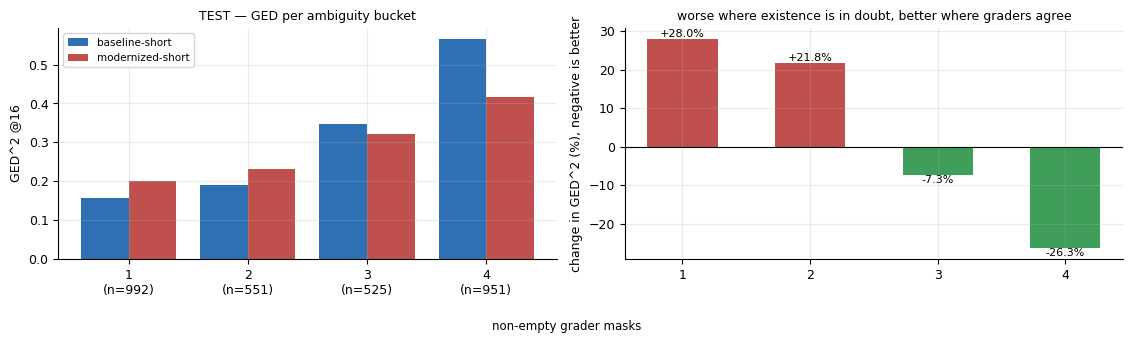

TEST — GED^2 @16 by ambiguity bucket
bucket  n    baseline-short  modernized-short  change   %     
------  ---  --------------  ----------------  -------  ------
1       992          0.1567            0.2005  +0.0439  +28.0%
2       551          0.1898            0.2313  +0.0415  +21.8%
3       525          0.3457            0.3203  -0.0254   -7.3%
4       951          0.5654            0.4167  -0.1487  -26.3%

change in GED^2 (%): 28.0% -> -26.3% across buckets, monotonically falling (steps -6.2, -29.2, -18.9)
bucket 4 alone contributes -0.0468 of an aggregate change of -0.0293


In [8]:
buckets = sorted(comp["variants"][arms[0]]["per_bucket"], key=int)
B = {a: comp["variants"][a]["per_bucket"] for a in arms}
b0 = [val(B[arms[0]][k], f"ged@{N}") for k in buckets]
b1 = [val(B[arms[1]][k], f"ged@{N}") for k in buckets]
npatch = [B[arms[0]][k]["n_patches"] for k in buckets]

pct = bucket_ged_figure(buckets, b0, b1, npatch, arms, N)

table(["bucket", "n", arms[0], arms[1], "change", "%"],
      [[k, f"{n:,}", f"{x0:.4f}", f"{x1:.4f}", f"{x1 - x0:+.4f}", f"{p:+.1f}%"]
       for k, n, x0, x1, p in zip(buckets, npatch, b0, b1, pct)],
      title=f"TEST — GED^2 @{N} by ambiguity bucket")

best = min(range(len(buckets)), key=lambda i: pct[i])
print()
print(describe_monotonicity(pct, "change in GED^2 (%)"))
print(f"bucket {buckets[best]} alone contributes "
      f"{(b1[best] - b0[best]) * npatch[best] / sum(npatch):+.4f} of an aggregate change "
      f"of {g1 - g0:+.4f}")

### The same patches under both arms

Three test patches, taken at the 5th, 50th and 95th percentile of the per-image GED
difference; the left block is `baseline-short` and the right `modernized-short`, 16 prior
samples each from the same patch and the same seed. A case must clear a minimum grader
footprint and a minimum non-empty sample count in both arms to be legible at all, a
threshold set after the first export was rendered and inspected, so the percentiles run
over the legible subpopulation rather than the whole split.

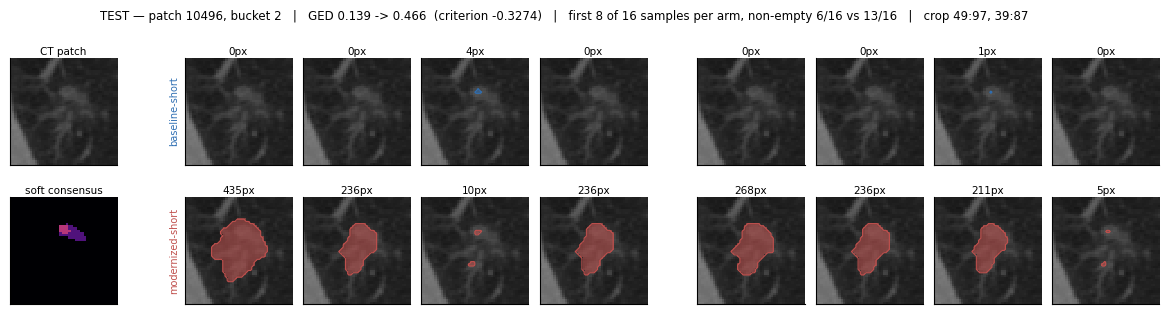

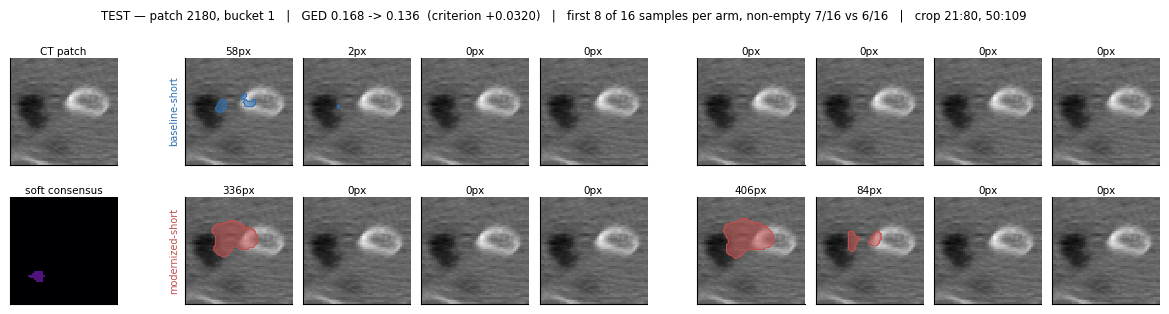

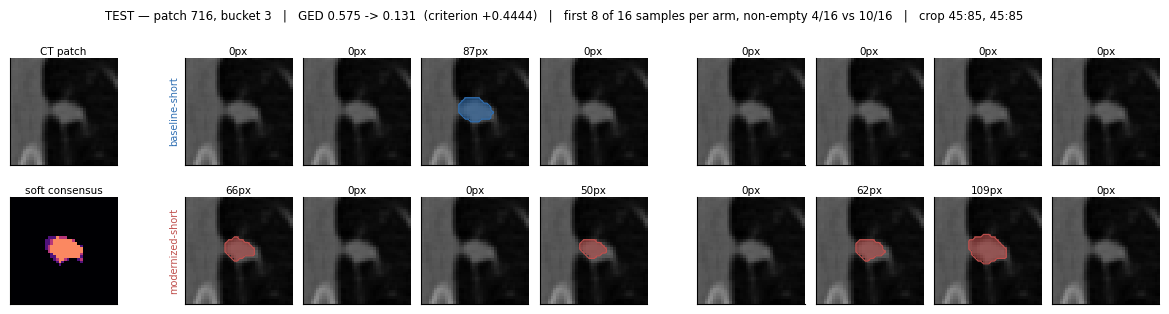

Set A legibility guard (set after the first export was inspected): grader-union footprint >= 25 px and >= 2 non-empty samples per arm, applied symmetrically to both arms. Eligible 2,251 of 3,019 test patches (74.6%); per bucket 1:495, 2:399, 3:452, 4:905.


In [9]:
for prefix in ("a0", "a1", "a2"):
    phase2_case_figure(SHOW, prefix)

print(set_a_guard_line(MAN))

---
# 4. Phase 3 — the consensus-selection head

The Probabilistic U-Net models ambiguity by producing a distribution over plausible
segmentations, but offers no principled way to choose one when a downstream decision has to
be made; the oracle, best-of-16, needs ground truth and is unusable at inference. The head
scores each sampled mask by how well it agrees with the graders and selects without ground
truth, regressing onto **soft-consensus Dice**. It is trained on a frozen base — the
optimizer never sees the base's parameters — and on **prior** samples rather than posterior
ones, since posterior samples have seen the ground-truth mask and are almost always good,
which teaches a head to emit a constant high score.

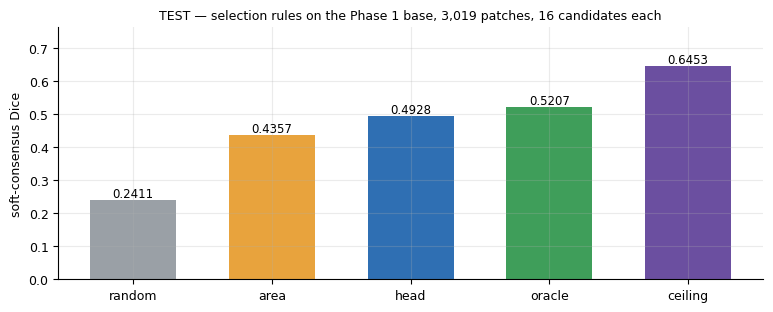

rule     what it is                                            
-------  ------------------------------------------------------
random        unselected draw — the mean over all 16 candidates
area      size prior: sees candidate area only, never the image
head                                         the selection head
oracle   best-of-16 — needs ground truth, unusable at inference
ceiling              the best score any binary mask could reach

The head beats the size prior by +0.0571 soft-consensus Dice, which is 67.2% of the headroom that rule
leaves. The size prior reduced to 'pick the largest candidate' on 100.0% of images, so it is a
deterministic rule rather than a learned scorer in disguise.


In [10]:
SEL = {"Phase 1 base": res("consensus_selection_test.json"),
       "Phase 2 base": res("consensus_selection_modernized_test.json")}
S1 = SEL["Phase 1 base"]["buckets"]["all"]

rules = [("random", "random", "unselected draw — the mean over all 16 candidates"),
         ("area", "area_only", "size prior: sees candidate area only, never the image"),
         ("head", "head", "the selection head"),
         ("oracle", "oracle", "best-of-16 — needs ground truth, unusable at inference"),
         ("ceiling", "ceiling", "the best score any binary mask could reach")]

score_bars([r[0] for r in rules], [val(S1, r[1]) for r in rules],
           f'TEST — selection rules on the Phase 1 base, {S1["n"]:,} patches, '
           f"16 candidates each")

table(["rule", "what it is"], [[lab, note] for lab, _, note in rules],
      note=f"\nThe head beats the size prior by "
           f'{float(S1["head_edge_over_area"]):+.4f} soft-consensus Dice, which is '
           f'{100 * float(S1["head_edge_frac_of_headroom_area_left"]):.1f}% of the '
           f"headroom that rule\nleaves. The size prior reduced to 'pick the largest "
           f"candidate' on {100 * val(S1, 'area_picks_largest'):.1f}% of images, so it is "
           f"a\ndeterministic rule rather than a learned scorer in disguise.")

The headline is the head's edge over that size prior rather than over a random draw: a rule
that sees only candidate area, and never the image, already captures most of the gap to the
oracle, because with three of four graders empty, "do not pick an empty candidate" is most
of the available gain. Both fractions are printed — of the total headroom (`e/tot`) and of
the headroom the size prior leaves (`e/left`) — because they are both arithmetically
correct and disagree in direction across the buckets, so neither trend is claimed as the
finding.

TEST — Phase 1 base, by ambiguity bucket
bucket     n      random  area    head    oracle  ceil    edge     e/tot  e/left  allmt
---------  -----  ------  ------  ------  ------  ------  -------  -----  ------  -----
1 grader     992  0.0735  0.1756  0.2108  0.2384  0.4000  +0.0352  21.4%   56.1%  0.114
2 graders    551  0.1658  0.3490  0.4157  0.4442  0.5833  +0.0666  23.9%   70.0%  0.074
3 graders    525  0.2556  0.5101  0.5838  0.6100  0.7347  +0.0736  20.8%   73.8%  0.057
4 graders    951  0.4515  0.7163  0.7815  0.8101  0.8878  +0.0652  18.2%   69.5%  0.019
all        3,019  0.2411  0.4357  0.4928  0.5207  0.6453  +0.0571  20.4%   67.2%  0.067

edge   = head - area          e/tot = edge / (oracle - random)
e/left = edge / (oracle - area)  allmt = fraction of images where every candidate was empty;
                                 those score 0 under every rule and cap any selector


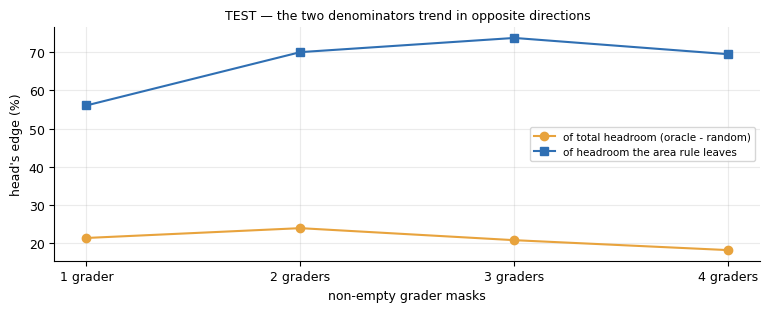

e/tot : 21.4% -> 18.2% across buckets, NOT monotone (steps +2.6, -3.1, -2.6)
e/left: 56.1% -> 69.5% across buckets, NOT monotone (steps +14.0, +3.7, -4.3)


In [11]:
bl = [k for k in SEL["Phase 1 base"]["buckets"] if k != "all"]
rows = []
for k in bl + ["all"]:
    r = SEL["Phase 1 base"]["buckets"][k]
    rows.append([k, f'{r["n"]:,}', f'{val(r, "random"):.4f}', f'{val(r, "area_only"):.4f}',
                 f'{val(r, "head"):.4f}', f'{val(r, "oracle"):.4f}',
                 f'{val(r, "ceiling"):.4f}', f'{float(r["head_edge_over_area"]):+.4f}',
                 f'{100 * float(r["head_edge_frac_of_total_headroom"]):.1f}%',
                 f'{100 * float(r["head_edge_frac_of_headroom_area_left"]):.1f}%',
                 f'{float(r["all_candidates_empty_fraction"]):.3f}'])
table(["bucket", "n", "random", "area", "head", "oracle", "ceil", "edge", "e/tot",
       "e/left", "allmt"], rows,
      title="TEST — Phase 1 base, by ambiguity bucket",
      note=("\nedge   = head - area          e/tot = edge / (oracle - random)\n"
            "e/left = edge / (oracle - area)  allmt = fraction of images where every "
            "candidate was empty;\n                                 those score 0 under "
            "every rule and cap any selector"))

et = [100 * float(SEL["Phase 1 base"]["buckets"][k]["head_edge_frac_of_total_headroom"])
      for k in bl]
el = [100 * float(SEL["Phase 1 base"]["buckets"][k]
                  ["head_edge_frac_of_headroom_area_left"]) for k in bl]
denominator_figure(bl, et, el)
print(describe_monotonicity(et, "e/tot "))
print(describe_monotonicity(el, "e/left"))

### One patch, all sixteen candidates

Tile titles are the true soft-consensus Dice of each candidate, and each rule's pick is
outlined. Two cases follow: the 95th-percentile case, where the head recovers the oracle
candidate, and the 5th-percentile case, where it loses to the largest-candidate rule. Both
come from a percentile rule registered before the test split was examined —
nearest-to-percentile rather than argmin/argmax, since single-pixel lesions make the
extremes of both criteria metric artifacts — and the record is printed underneath.

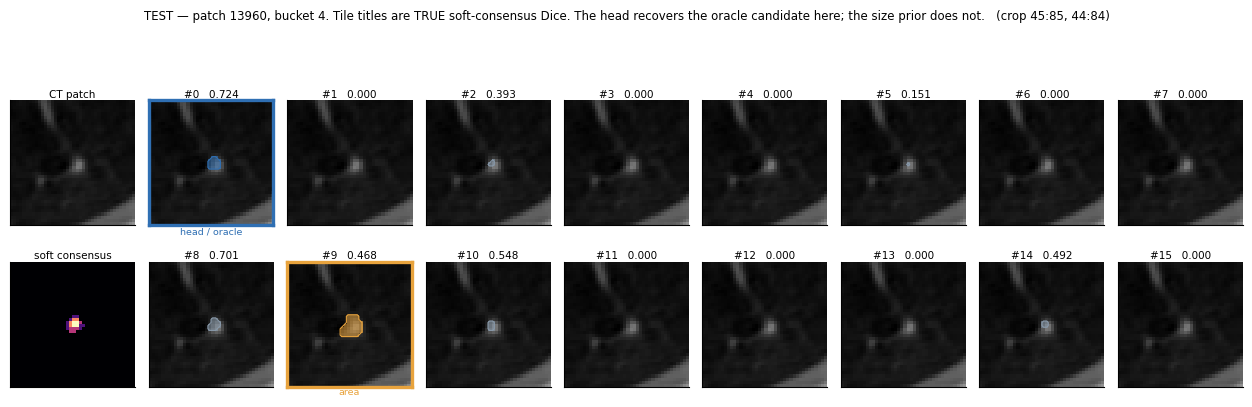

rule              picked  true score  candidate area               
----------------  ------  ----------  -----------------------------
head                  #0      0.7238                          14 px
area                  #9      0.4683                          39 px
oracle                #0      0.7238                          14 px
ceiling                —      0.7619                              —
mean over all 16       —      0.2174  the published 'random' column



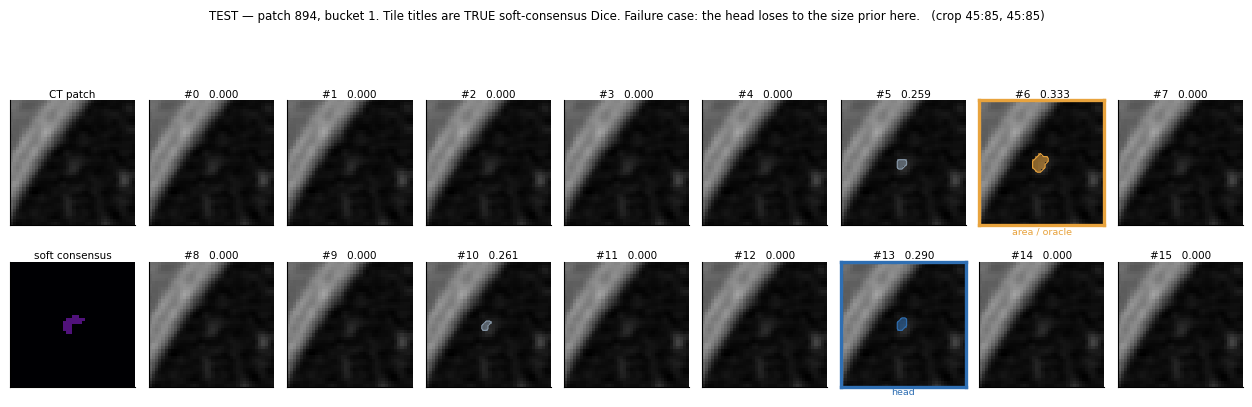

rule              picked  true score  candidate area               
----------------  ------  ----------  -----------------------------
head                 #13      0.2903                          10 px
area                  #6      0.3333                          20 px
oracle                #6      0.3333                          20 px
ceiling                —      0.4000                              —
mean over all 16       —      0.0715  the published 'random' column

Shortfall against the size prior: -0.0430 soft-consensus Dice, in bucket 1, where the ceiling is 0.4000.


In [12]:
selection_case_figure(SHOW, "b2", "The head recovers the oracle candidate here; the size "
                                  "prior does not.")
print()
selection_case_figure(SHOW, "b0", "Failure case: the head loses to the size prior here.")
c = case("b0")
print(f'\nShortfall against the size prior: {float(c["criterion"]):+.4f} soft-consensus '
      f'Dice, in bucket {int(c["bucket"])}, where the ceiling is '
      f'{float(c["ceiling"]):.4f}.')

In [13]:
table(["set", "key", "percentile", "patch", "bucket", "criterion", "value at pctile"],
      [[r["set"], r["key_prefix"], f'{r["percentile"]:.0f}th', r["patch_index"],
        r["bucket"], f'{r["criterion"]:+.4f}', f'{r["percentile_value"]:+.4f}']
       for r in MAN["selection_record"]],
      title="Case selection record, printed from the export manifest")
print()
for k, v in MAN["criteria"].items():
    print(f"  set {k} criterion: {v}")
print(f'\n  percentiles targeted : {MAN["case_percentiles"]}')
print(f'  duplicate selections : {MAN["duplicate_case_positions"]}')
print("\n  eligibility guards, applied before the percentiles and counted rather than "
      "dropped silently:")
for name, g in MAN["guards"].items():
    print(f"    {name}: " + ", ".join(f"{k}={v}" for k, v in g.items()
                                      if k not in ("note", "per_bucket_eligible")))

Case selection record, printed from the export manifest
set  key  percentile  patch  bucket  criterion  value at pctile
---  ---  ----------  -----  ------  ---------  ---------------
A     a0         5th  10496       2    -0.3274          -0.3265
A     a1        50th   2180       1    +0.0320          +0.0320
A     a2        95th    716       3    +0.4444          +0.4448
B     b0         5th    894       1    -0.0430          -0.0430
B     b1        50th   5537       1    +0.0378          +0.0379
B     b2        95th  13960       4    +0.2555          +0.2557

  set A criterion: per-image GED at n=16, baseline-short minus modernized-short (positive = modernized better)
  set B criterion: per-image soft-consensus Dice of the head's pick minus the area control's pick, Phase 1 base (negative = the head lost to the largest-candidate rule)

  percentiles targeted : [5.0, 50.0, 95.0]
  duplicate selections : {'set_a': [], 'set_b': []}

  eligibility guards, applied before the percentiles a

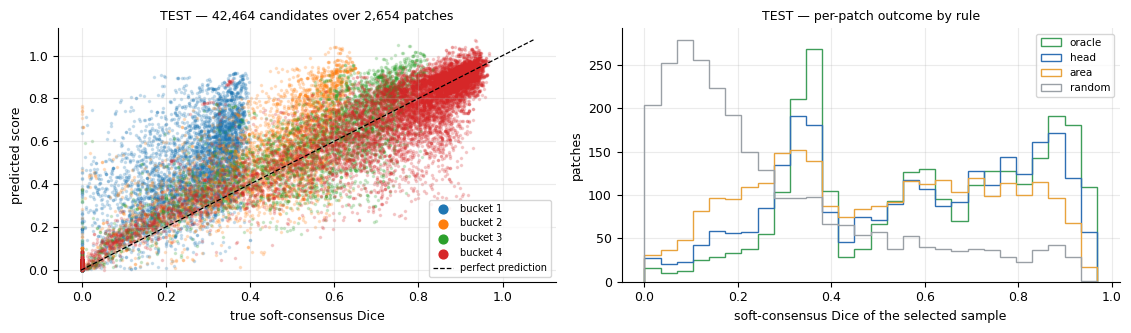

Pearson correlation between predicted and true candidate scores: 0.9410
Per-image Spearman: head 0.900 against 0.804 for the size prior, an increment of +0.096 -- most of the ranking signal in this task is size.
Images excluded from Spearman because every candidate tied: 0.121, counted rather than dropped.


In [14]:
rho = score_agreement_figure(SHOW)
print(f"Pearson correlation between predicted and true candidate scores: {rho:.4f}")
print(f"Per-image Spearman: head {val(S1, 'head_spearman'):.3f} against "
      f"{val(S1, 'area_spearman'):.3f} for the size prior, an increment of "
      f"{val(S1, 'head_spearman') - val(S1, 'area_spearman'):+.3f} -- most of the ranking "
      f"signal in this task is size.")
print(f"Images excluded from Spearman because every candidate tied: "
      f"{float(S1['head_spearman_excluded_fraction']):.3f}, counted rather than dropped.")

In [15]:
base_ev = res("evaluation_test_baseline.json")["aggregate_over_all_patches"]
head_ev = res("evaluation_test_selection-head.json")["aggregate_over_all_patches"]
keys = [f"ged@{N}", f"ged_ys@{N}", f"ged_ss@{N}", f"ged_yy@{N}",
        f"random_sample_dice@{N}", f"oracle_dice@{N}", f"hungarian_iou@{N}"]

table(["metric", "baseline", "baseline + head", "check"],
      [[k, f"{val(base_ev, k):.6f}", f"{val(head_ev, k):.6f}",
        "identical" if val(base_ev, k) == val(head_ev, k) else "DIFFERS"] for k in keys],
      title="TEST — the extension's first claim: distribution metrics unchanged",
      note=f"\nAll {sum(val(base_ev, k) == val(head_ev, k) for k in keys)} of {len(keys)} "
           f"metrics are bit-identical with and without the head. Guaranteed by a frozen\n"
           f"base, and here also observed through the evaluation entry point on held-out "
           f"data.")

TEST — the extension's first claim: distribution metrics unchanged
metric                 baseline  baseline + head  check    
---------------------  --------  ---------------  ---------
ged@16                 0.321131         0.321131  identical
ged_ys@16              0.574361         0.574361  identical
ged_ss@16              0.438086         0.438086  identical
ged_yy@16              0.389505         0.389505  identical
random_sample_dice@16  0.462149         0.462149  identical
oracle_dice@16         0.685743         0.685743  identical
hungarian_iou@16       0.763501         0.763501  identical

All 7 of 7 metrics are bit-identical with and without the head. Guaranteed by a frozen
base, and here also observed through the evaluation entry point on held-out data.


---
# 5. Composition

Phase 2 improved GED and Phase 3 improves the selected output, so stacking them ought to
compound — it does not. Phase 2 raised the floor, a random draw, without raising the
ceiling, the oracle, so there is less headroom left to select from; this follows directly
from the sharpening of section 3. The defensible claim is the null: Phase 2's GED gain did
not translate into better selected output, and the two pipelines are **not** ranked here,
because the difference between them is smaller than the epoch-to-epoch band of the
validation monitor the head's checkpoint was chosen on. What buys confidence in the null is
that both splits agree in sign and in magnitude.

The same selection head on both frozen bases
quantity              TEST P1  TEST P2  TEST delta  VAL P1  VAL P2  VAL delta
--------------------  -------  -------  ----------  ------  ------  ---------
random (the floor)     0.2411   0.2824     +0.0413  0.2349  0.2799    +0.0450
oracle (the ceiling)   0.5207   0.5177     -0.0030  0.5244  0.5215    -0.0029
head-selected output   0.4928   0.4859     -0.0069  0.4940  0.4889    -0.0052
selectable headroom    0.2796   0.2353     -0.0443  0.2895  0.2416    -0.0479


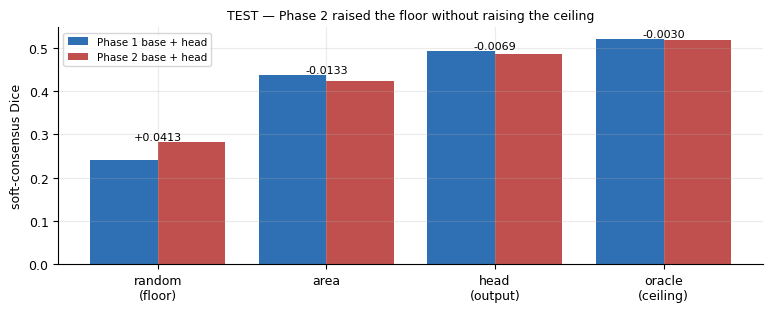

If the system outputs a selected mask, Phase 2 buys -0.0069; if it outputs a random sample, it buys +17%.


In [16]:
VAL_SEL = {"Phase 1 base": res("consensus_selection_val.json"),
           "Phase 2 base": res("consensus_selection_modernized_val.json")}
A1, A2 = SEL["Phase 1 base"]["buckets"]["all"], SEL["Phase 2 base"]["buckets"]["all"]
V1, V2 = (VAL_SEL["Phase 1 base"]["buckets"]["all"],
          VAL_SEL["Phase 2 base"]["buckets"]["all"])
headroom = lambda b: val(b, "oracle") - val(b, "random")   # noqa: E731

rows = [
    ["random (the floor)", A1, A2, V1, V2, "random"],
    ["oracle (the ceiling)", A1, A2, V1, V2, "oracle"],
    ["head-selected output", A1, A2, V1, V2, "head"],
]
table(["quantity", "TEST P1", "TEST P2", "TEST delta", "VAL P1", "VAL P2", "VAL delta"],
      [[r[0], f"{val(r[1], r[5]):.4f}", f"{val(r[2], r[5]):.4f}",
        f"{val(r[2], r[5]) - val(r[1], r[5]):+.4f}", f"{val(r[3], r[5]):.4f}",
        f"{val(r[4], r[5]):.4f}", f"{val(r[4], r[5]) - val(r[3], r[5]):+.4f}"]
       for r in rows]
      + [["selectable headroom", f"{headroom(A1):.4f}", f"{headroom(A2):.4f}",
          f"{headroom(A2) - headroom(A1):+.4f}", f"{headroom(V1):.4f}",
          f"{headroom(V2):.4f}", f"{headroom(V2) - headroom(V1):+.4f}"]],
      title="The same selection head on both frozen bases")

composition_figure(["random\n(floor)", "area", "head\n(output)", "oracle\n(ceiling)"],
                   [val(A1, k) for k in ("random", "area_only", "head", "oracle")],
                   [val(A2, k) for k in ("random", "area_only", "head", "oracle")],
                   ["Phase 1 base + head", "Phase 2 base + head"],
                   "TEST — Phase 2 raised the floor without raising the ceiling")

print(f"If the system outputs a selected mask, Phase 2 buys "
      f'{val(A2, "head") - val(A1, "head"):+.4f}; if it outputs a random sample, it buys '
      f'{100 * (val(A2, "random") - val(A1, "random")) / val(A1, "random"):+.0f}%.')

---
# 6. Limitations

Each line is measured from the tracked results files rather than asserted.

In [17]:
edge_delta = [(k, float(SEL["Phase 2 base"]["buckets"][k]["head_edge_over_area"])
                  - float(SEL["Phase 1 base"]["buckets"][k]["head_edge_over_area"]))
              for k in bl]
flat = min(edge_delta, key=lambda r: abs(r[1]))
dirty = ", ".join(f'{name} {v["checkpoint_git_revision"]}'
                  for name, v in MAN["variants"].items()
                  if "dirty" in (v["checkpoint_git_revision"] or ""))

table(["#", "limitation", "measured"], [
    ["1", "one seed per arm",
     f'{len(MAN["variants"])} runs, one seed each; no interval here is a distribution '
     f"over seeds"],
    ["2", "the test split is harder for any selector",
     f'every candidate empty {float(V1["all_candidates_empty_fraction"]):.3f} VAL -> '
     f'{float(A1["all_candidates_empty_fraction"]):.3f} TEST'],
    ["3", "the head's per-bucket trend depends on the denominator",
     f"e/tot {et[0]:.0f}% -> {et[-1]:.0f}%, e/left {el[0]:.0f}% -> {el[-1]:.0f}% "
     f"across buckets"],
    ["4", "one checkpoint carries a dirty git revision", dirty],
    ["5", "only the aggregate edge refutation may be restated",
     f'edge over the size prior {float(A1["head_edge_over_area"]):+.4f} -> '
     f'{float(A2["head_edge_over_area"]):+.4f} on the Phase 2 base, but bucket '
     f"{flat[0]} moved {flat[1]:+.4f}"],
    ["6", "the head's checkpoint was selected on the metric it reports",
     f'head {val(V1, "head"):.4f} VAL -> {val(A1, "head"):.4f} TEST '
     f'({val(A1, "head") - val(V1, "head"):+.4f}); DEVIATIONS 14'],
], note="\n2. Images where every candidate is empty score 0 under every rule, so part of "
        "any val-to-test decline is\n   the split being harder rather than the head "
        "generalizing worse -- a limit of the base sampler.\n"
        "5. The edge grew because the size-only rule degraded faster on a more "
        "concentrated candidate set, not\n   because the head improved; the per-bucket "
        "version of that claim held on VAL and did not survive TEST.\n"
        "6. The pre-registered band quoted in DEVIATIONS 14 predates the size-prior "
        "control and was itself\n   miscalibrated: the control alone scores above the "
        "whole band.")

#  limitation                                                   measured                                                                                           
-  -----------------------------------------------------------  ---------------------------------------------------------------------------------------------------
1                                             one seed per arm                                 4 runs, one seed each; no interval here is a distribution over seeds
2                    the test split is harder for any selector                                                        every candidate empty 0.048 VAL -> 0.067 TEST
3       the head's per-bucket trend depends on the denominator                                                   e/tot 21% -> 18%, e/left 56% -> 69% across buckets
4                  one checkpoint carries a dirty git revision                                                                       modernized_short 31a50e6-dirty
5           only

---
# 7. Training from scratch on a small subset

This section trains a deliberately undersized model on the tracked 288-patch subset through
the real `scripts/train.py`, to show that the pipeline runs end to end inside a session
like Colab's; its metrics are reported nowhere and its weights are deleted at the end.
TensorBoard is off for this config, because subset row indices and the diagnostic panel's
full-dataset numbering coincide only on the full dataset (`DEVIATIONS.md`, entry 15).
Validation here is 32 patches over 16 steps per epoch, so the tail of the curve is sampling
noise.

In [18]:
from probunet.data.lidc import LidcArrays, build_data
from probunet.data.splits import load_split
from probunet.training.config import ExperimentConfig

DEMO_CFG = ROOT / "configs" / "colab_demo.yaml"
cfg = ExperimentConfig.from_yaml(DEMO_CFG)
arrays = LidcArrays.load(cfg.data.npz_path)
split = load_split(cfg.data.split_path, expected_n_patches=len(arrays))
data = build_data(cfg.data)
bucket_counts = arrays.nonempty_counts()

table(["field", "value"], [
    ["subset file", str(cfg.data.npz_path)],
    ["size on disk", f"{Path(cfg.data.npz_path).stat().st_size / 1024**2:.2f} MiB"],
    ["patches", f"{len(arrays):,}"],
    ["ambiguity buckets", ", ".join(f"{b}: {int((bucket_counts == b).sum())}"
                                    for b in (1, 2, 3, 4))],
    ["train / val / test", f'{len(data.datasets["train"])} / '
                          f'{len(data.datasets["val"])} / {len(data.datasets["test"])}'],
    ["budget", f"{cfg.train.iterations} iterations, batch {cfg.data.batch_size}"],
    ["augmentation", str(cfg.data.augmentation.enabled)],
    ["tensorboard", str(cfg.log.tensorboard)],
], title="The demo subset, loaded through the real dataset class",
   note="\nThe test partition is empty by construction: no test patch was drawn into this "
        "subset.")

import subprocess, sys, time

t0 = time.time()
proc = subprocess.run(
    [sys.executable, "scripts/train.py", "--config", str(DEMO_CFG)],
    cwd=ROOT, capture_output=True, text=True,
)
tail = [ln for ln in proc.stdout.splitlines() + proc.stderr.splitlines()
        if "epoch" in ln or "device" in ln or "budget" in ln or "finished" in ln]
print("\n".join(tail[-12:]))
print(f"\nreturn code {proc.returncode}, wall clock {time.time() - t0:.0f} s")
if proc.returncode != 0:
    print("\n--- stderr tail ---\n" + "\n".join(proc.stderr.splitlines()[-25:]))
assert proc.returncode == 0, "the demo training run failed; see the stderr tail above"

The demo subset, loaded through the real dataset class
field               value                             
------------------  ----------------------------------
subset file         data/processed/lidc_colab_demo.npz
size on disk                                  8.32 MiB
patches                                            288
ambiguity buckets           1: 72, 2: 72, 3: 72, 4: 72
train / val / test                        256 / 32 / 0
budget                         128 iterations, batch 4
augmentation                                      True
tensorboard                                      False

The test partition is empty by construction: no test patch was drawn into this subset.
15:43:58 INFO    probunet.training.checkpoint | wrote checkpoint runs/colab_demo/checkpoints/last.pt (epoch 5, step 80)
15:45:21 INFO    probunet.training.trainer | epoch 6/8 train/total=804.1812 train/ce=801.2598 train/kl=2.9214 val/total=581.0662 diag/gap_total=-223.1151 eta=2.4 min
15:45:28 INFO    prob

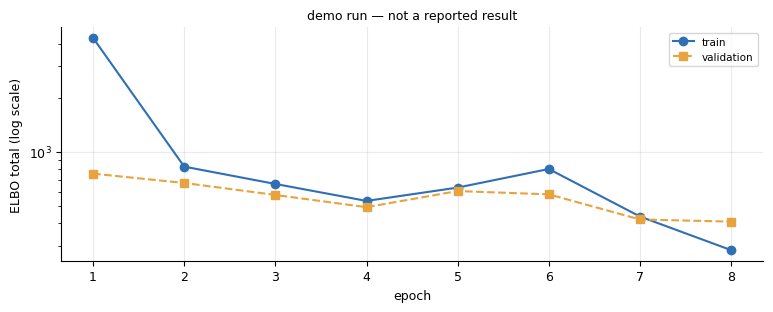

train ELBO 4313.1 -> 284.3 (-93.4%) over 8 epochs / 128 steps; monitored val/total, best 409.6037


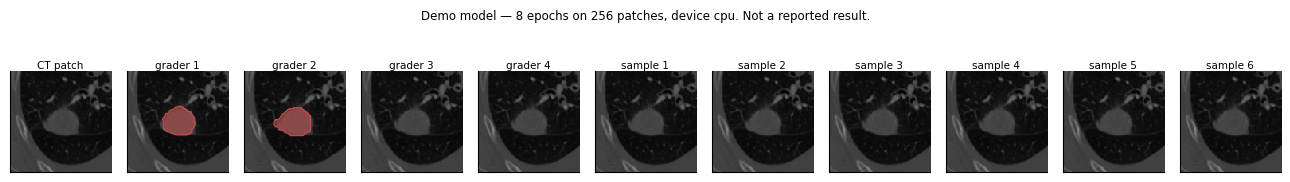

non-empty demo samples: 0 of 6. Background pixels vastly outnumber lesion pixels, so a short run learns the background prior first.
demo run directory removed: /content/prob-unet-consensus-selection/runs/colab_demo


In [19]:
import shutil

import torch
from probunet.evaluation.sampling import draw_prior_samples
from probunet.model.prob_unet import ProbUNet
from probunet.training.checkpoint import load_checkpoint
from probunet.utils.runtime import select_device

run_dir = ROOT / cfg.run.out_dir / cfg.run.name
summary = json.loads((run_dir / "summary.json").read_text())
demo_loss_figure(summary["history"])
losses = [h["train/total"] for h in summary["history"]]
print(f"train ELBO {losses[0]:.1f} -> {losses[-1]:.1f} "
      f"({100 * (losses[-1] - losses[0]) / losses[0]:+.1f}%) over {summary['epochs']} "
      f"epochs / {summary['global_step']} steps; monitored {summary['monitor']}, best "
      f"{summary['best_metric']:.4f}")

device = select_device(cfg.run.device)
model = ProbUNet(cfg.model).to(device)
state = load_checkpoint(run_dir / "checkpoints" / "best.pt", model=model,
                        map_location=device, restore_rng=False)
model.eval()

# The demo val patch with the most grader agreement, so the panel has something to show.
val_batch = next(iter(torch.utils.data.DataLoader(
    data.datasets["val"], batch_size=len(data.datasets["val"]), shuffle=False)))
pick = int(val_batch["masks"].flatten(1).sum(1).argmax())
image = val_batch["image"][pick:pick + 1].to(device)
samples = draw_prior_samples(model, image, 6, torch.Generator().manual_seed(2018))
smp = samples[0].cpu().numpy()

demo_samples_figure(
    image[0, 0].cpu().numpy(), val_batch["masks"][pick].numpy(), smp,
    f"Demo model — {state.epoch} epochs on {len(data.datasets['train'])} patches, device "
    f"{device}. Not a reported result.")
print(f"non-empty demo samples: {int((smp.reshape(len(smp), -1).sum(1) > 0).sum())} of "
      f"{len(smp)}. Background pixels vastly outnumber lesion pixels, so a short run "
      f"learns the background prior first.")

del model
shutil.rmtree(run_dir, ignore_errors=True)
print(f"demo run directory removed: {run_dir}")

---
# 8. Test suite

The suite runs on CPU with no accelerator and no full dataset; tests that need a CUDA
device or the untracked 450 MB `lidc.npz` skip cleanly, so the skip count is higher here
than on the machine that trained the models. One test is deselected with
`-m "not version_sensitive"`: `test_phase1_latent_path_is_unchanged` pins the Phase 1
latent path to exact float values, which ties it to the NumPy and torch build it was
recorded under.

In [20]:
import subprocess, sys

proc = subprocess.run(
    [sys.executable, "-m", "pytest", "-m", "not version_sensitive", "-q", "--no-header",
     "--color=no", "-p", "no:cacheprovider", "-rs"],
    cwd=ROOT, capture_output=True, text=True,
)
lines = [ln for ln in proc.stdout.splitlines()
         if ln.startswith(("SKIPPED", "FAILED", "ERROR")) or " passed" in ln
         or " failed" in ln or " error" in ln]
print("\n".join(lines) or proc.stdout[-2000:])
print(f"\nreturn code {proc.returncode} "
      f"({'PASS' if proc.returncode == 0 else 'FAIL'})")

SKIPPED [1] tests/test_data.py:669: converted dataset absent
SKIPPED [1] tests/test_data.py:682: converted dataset absent
SKIPPED [1] tests/test_elbo.py:520: converted dataset absent
SKIPPED [1] tests/test_splits.py:450: converted dataset not present
SKIPPED [1] tests/test_splits.py:489: converted dataset not present
SKIPPED [1] tests/test_training.py:1381: no CUDA device available
SKIPPED [1] tests/test_training.py:1383: no MPS device available
SKIPPED [1] tests/test_training.py:1418: no accelerator available
SKIPPED [1] tests/test_training.py:1454: no accelerator available
538 passed, 9 skipped, 1 deselected in 54.03s

return code 0 (PASS)


---
## Findings

1. **Phase 2's outcome was confirmed and its mechanism refuted.** Full covariance improved
   GED by close to the figure independently published for the same change on the same data,
   but it did so by sharpening the sample distribution rather than broadening it, and its
   per-bucket effect reverses monotonically in ambiguity.
2. **The selection head's honest measure is its edge over a size prior**, not over a random
   draw; it recovers most of the headroom that prior leaves, and that fraction is stable
   across two bases and two splits.
3. **The two extensions do not compose.** Phase 2 raised the floor without raising the
   ceiling, leaving less to select; the result is reported as a null and the two pipelines
   are not ranked.

`DEVIATIONS.md` lists every departure from the paper, `configs/` records what each
comparison changed, and `results/` holds every number above.